# PHY 657 — Module 4 Homework _ Belal Menbari
## Spring 2026

---

## Setup

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})

# reproducibility
RNG = np.random.default_rng(42)

### Helper: `plot_decision_boundary`

Same function from Day 2 notebook.

In [22]:
def plot_decision_boundary(clf, X, y, ax=None, title='', feature_names=None, class_names=None):
    """Plot 2D decision boundary with probability shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    
    colors = ['tab:blue', 'tab:green']
    for c in np.unique(y):
        sel = y == c
        label = class_names[c] if class_names is not None else f'class {c}'
        ax.scatter(X[sel, 0], X[sel, 1], c=colors[c], edgecolors='k', label=label, alpha=0.8)
    
    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
    ax.legend()
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, label='$P(y{=}1 \\mid \\mathbf{x})$')
    return ax

---
## Problem 1: Generating Data

Two 2D Gaussian clusters:

$$\mathbf{x}_0 \sim \mathcal{N}\!\left(\begin{pmatrix}0\\0\end{pmatrix},\; I\right), \qquad \mathbf{x}_1 \sim \mathcal{N}\!\left(\begin{pmatrix}\mu\\0\end{pmatrix},\; I\right)$$

Each point $\mathbf{x} = (x_1, x_2)$ lives in feature space. Label $y \in \{0,1\}$.

In [23]:
def generate_data(mu, n_per_class=200, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    
    # class 0: mean = (0, 0)
    X0 = rng.standard_normal((n_per_class, 2))
    
    # class 1: mean = (mu, 0)
    X1 = rng.standard_normal((n_per_class, 2))
    X1[:, 0] += mu
    
    X = np.vstack([X0, X1])
    y = np.array([0]*n_per_class + [1]*n_per_class)
    
    return X, y

### 1.1 & 1.2  Plot for $\mu = 3$, colored by class

Samples: 400  (class 0: 200, class 1: 200)


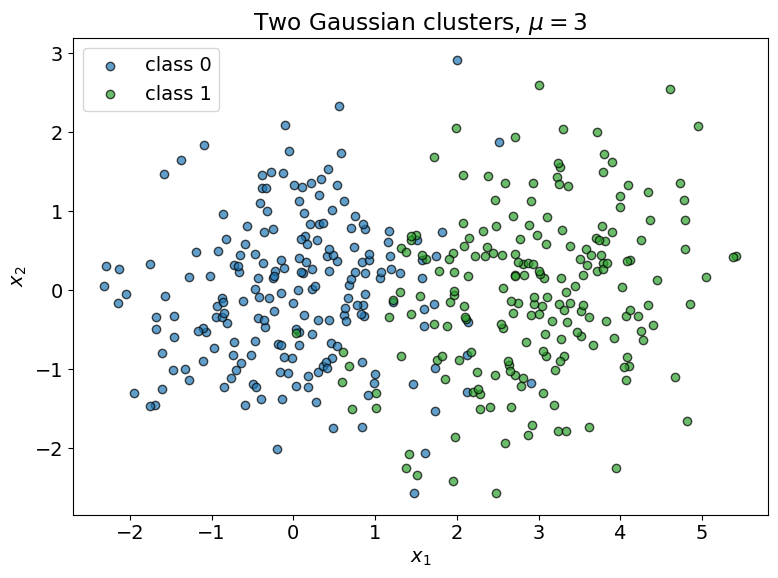

In [24]:
mu = 3
X, y = generate_data(mu, rng=np.random.default_rng(42))

print(f"Samples: {len(y)}  (class 0: {(y==0).sum()}, class 1: {(y==1).sum()})")

fig, ax = plt.subplots()
for c, label, color in zip([0, 1], ['class 0', 'class 1'], ['tab:blue', 'tab:green']):
    sel = y == c
    ax.scatter(X[sel, 0], X[sel, 1], c=color, label=label, edgecolors='k', alpha=0.7)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(f'Two Gaussian clusters, $\\mu = {mu}$')
ax.legend()
plt.tight_layout()
plt.show()

Clusters are well separated along $x_1$.

---
## Problem 2: Linear Classifier

From the lectures, define the linear function:

$$g(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b$$

Decision rule:

$$\hat{y} = \begin{cases} 1 & g(\mathbf{x}) > 0 \\ 0 & g(\mathbf{x}) < 0 \end{cases}$$

Probabilistic version — apply the sigmoid:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

$$P(y=1 \mid \mathbf{x}) = \sigma\!\left(g(\mathbf{x})\right) = \sigma\!\left(\mathbf{w}^T \mathbf{x} + b\right)$$

Linear boundary + squashing function = classifier.

The decision boundary is where $P = 0.5$:

$$\sigma\!\left(g(\mathbf{x})\right) = 0.5$$

$$\Rightarrow \quad g(\mathbf{x}) = 0$$

$$\Rightarrow \quad \mathbf{w}^T \mathbf{x} + b = 0$$

Expand in 2D:

$$w_1 x_1 + w_2 x_2 + b = 0$$

Solve for $x_2$:

$$w_2 x_2 = -w_1 x_1 - b$$

$$x_2 = -\frac{w_1}{w_2}\, x_1 - \frac{b}{w_2}$$

This is a line. In 3D it would be a plane, in general a hyperplane.

### 2.1 Fit

In [30]:
clf = LogisticRegression()
clf.fit(X, y)

w = clf.coef_[0]
b = clf.intercept_[0]

print(f"w = [{w[0]:.4f}, {w[1]:.4f}]")
print(f"b = {b:.4f}")
print(f"\ng(x) = ({w[0]:.3f})*x1 + ({w[1]:.3f})*x2 + ({b:.3f})")
print(f"\nBoundary line:  x2 = -({w[0]:.3f}/{w[1]:.3f})*x1 - ({b:.3f}/{w[1]:.3f})")
print(f"             => x2 = {-w[0]/w[1]:.3f}*x1 + {-b/w[1]:.3f}")
print(f"\nAccuracy = {clf.score(X, y):.2%}")

w = [2.5868, -0.3212]
b = -3.8024

g(x) = (2.587)*x1 + (-0.321)*x2 + (-3.802)

Boundary line:  x2 = -(2.587/-0.321)*x1 - (-3.802/-0.321)
             => x2 = 8.053*x1 + -11.838

Accuracy = 91.50%


### 2.2 Decision boundary + probability regions

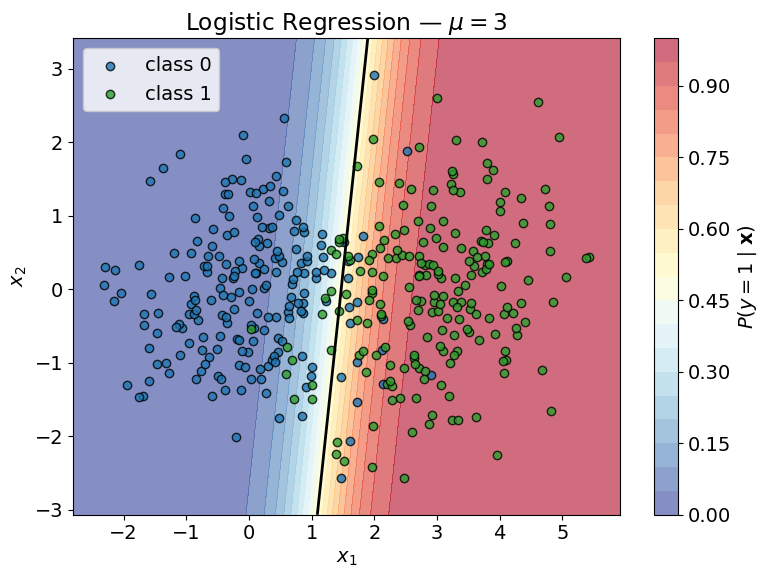

In [31]:
plot_decision_boundary(
    clf, X, y,
    title=f'Logistic Regression — $\\mu = {mu}$',
    feature_names=['$x_1$', '$x_2$'],
    class_names=['class 0', 'class 1']
)
plt.tight_layout()
plt.show()

Black line = decision boundary $g(\mathbf{x}) = 0$. Color = $P(y=1\mid\mathbf{x})$.

---
## Problem 3: Performance vs Separation

Repeat for $\mu = 3,\, 2,\, 1,\, 0.5$.

From the confusion matrix:

|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actually Positive** | TP | FN |
| **Actually Negative** | FP | TN |

Metrics:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{FPR (background leakage)} = \frac{FP}{FP + TN}$$

$$\text{Efficiency (TPR)} = \frac{TP}{TP + FN}$$

$$\text{FNR} = 1 - \text{Efficiency} = 1 - \frac{TP}{TP + FN} = \frac{TP + FN - TP}{TP + FN} = \frac{FN}{TP + FN}$$

=== mu = 3 ===
  TP = 184,  TN = 182,  FP = 18,  FN = 16
  Accuracy = (TP + TN) / (TP + TN + FP + FN)
           = (184 + 182) / (184 + 182 + 18 + 16)
           = 366 / 400
           = 0.915
  FPR      = FP / (FP + TN)
           = 18 / (18 + 182)
           = 18 / 200
           = 0.090
  FNR      = FN / (FN + TP)
           = 16 / (16 + 184)
           = 16 / 200
           = 0.080

=== mu = 2 ===
  TP = 163,  TN = 169,  FP = 31,  FN = 37
  Accuracy = (TP + TN) / (TP + TN + FP + FN)
           = (163 + 169) / (163 + 169 + 31 + 37)
           = 332 / 400
           = 0.830
  FPR      = FP / (FP + TN)
           = 31 / (31 + 169)
           = 31 / 200
           = 0.155
  FNR      = FN / (FN + TP)
           = 37 / (37 + 163)
           = 37 / 200
           = 0.185

=== mu = 1 ===
  TP = 137,  TN = 138,  FP = 62,  FN = 63
  Accuracy = (TP + TN) / (TP + TN + FP + FN)
           = (137 + 138) / (137 + 138 + 62 + 63)
           = 275 / 400
           = 0.688
  FPR      = FP / (FP + TN)

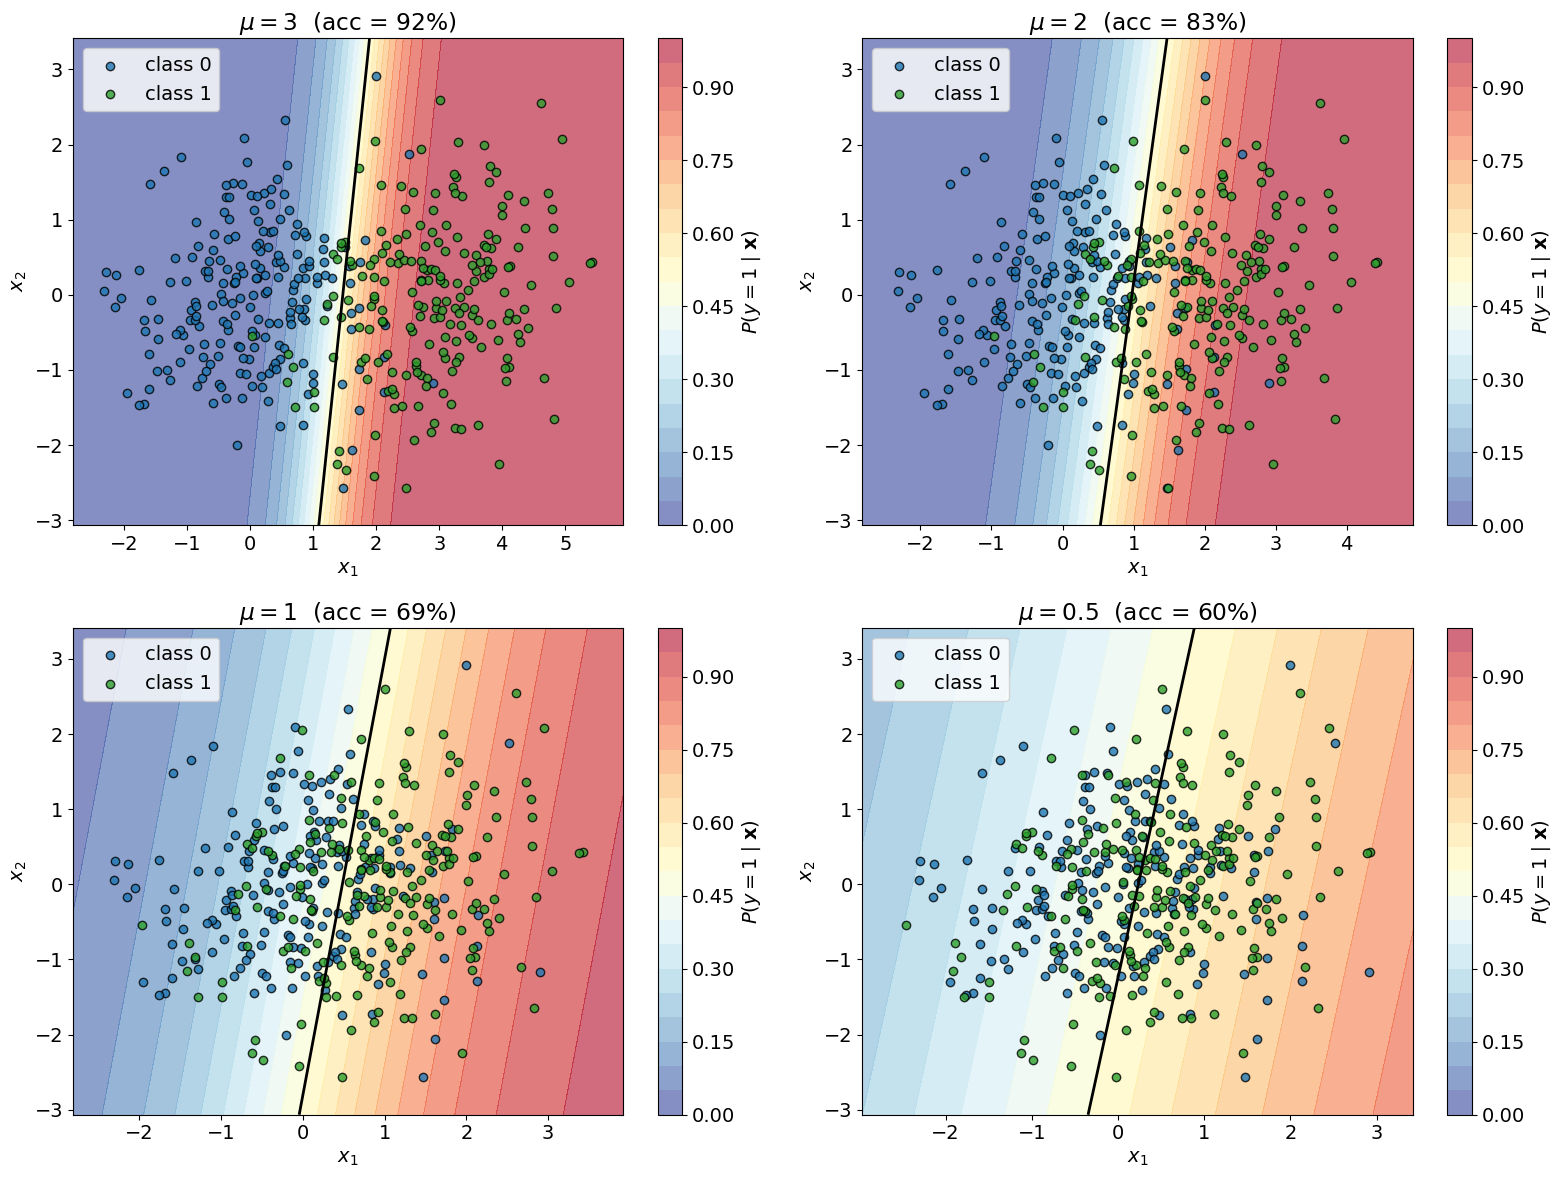

In [32]:
mu_values = [3, 2, 1, 0.5]
results = []

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, mu_val in enumerate(mu_values):
    ax = axes.flat[idx]
    
    X_i, y_i = generate_data(mu_val, rng=np.random.default_rng(42))
    
    clf_i = LogisticRegression()
    clf_i.fit(X_i, y_i)
    y_pred_i = clf_i.predict(X_i)
    
    # confusion matrix: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_i, y_pred_i)
    TN, FP, FN, TP = cm.ravel()
    
    # --- show all arithmetic ---
    acc = (TP + TN) / (TP + TN + FP + FN)
    fpr = FP / (FP + TN)
    fnr = FN / (FN + TP)
    
    results.append((mu_val, acc, fpr, fnr))
    
    print(f'=== mu = {mu_val} ===')
    print(f'  TP = {TP},  TN = {TN},  FP = {FP},  FN = {FN}')
    print(f'  Accuracy = (TP + TN) / (TP + TN + FP + FN)')
    print(f'           = ({TP} + {TN}) / ({TP} + {TN} + {FP} + {FN})')
    print(f'           = {TP + TN} / {TP + TN + FP + FN}')
    print(f'           = {acc:.3f}')
    print(f'  FPR      = FP / (FP + TN)')
    print(f'           = {FP} / ({FP} + {TN})')
    print(f'           = {FP} / {FP + TN}')
    print(f'           = {fpr:.3f}')
    print(f'  FNR      = FN / (FN + TP)')
    print(f'           = {FN} / ({FN} + {TP})')
    print(f'           = {FN} / {FN + TP}')
    print(f'           = {fnr:.3f}')
    print()
    
    plot_decision_boundary(
        clf_i, X_i, y_i, ax=ax,
        title=f'$\\mu = {mu_val}$  (acc = {acc:.0%})',
        feature_names=['$x_1$', '$x_2$'],
        class_names=['class 0', 'class 1']
    )

plt.tight_layout()
plt.show()

### Confusion matrices

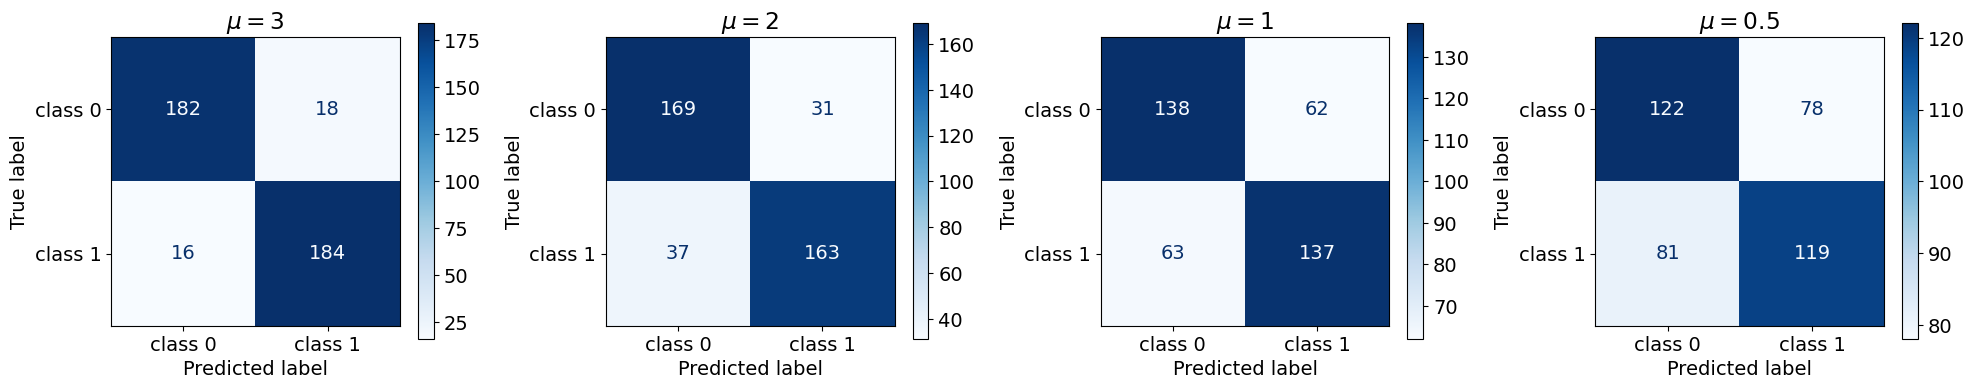

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, mu_val in enumerate(mu_values):
    X_i, y_i = generate_data(mu_val, rng=np.random.default_rng(42))
    clf_i = LogisticRegression()
    clf_i.fit(X_i, y_i)
    y_pred_i = clf_i.predict(X_i)
    
    cm = confusion_matrix(y_i, y_pred_i)
    ConfusionMatrixDisplay(cm, display_labels=['class 0', 'class 1']).plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'$\\mu = {mu_val}$')

plt.tight_layout()
plt.show()

Off-diagonals grow as $\mu$ shrinks.

### Accuracy vs $\mu$

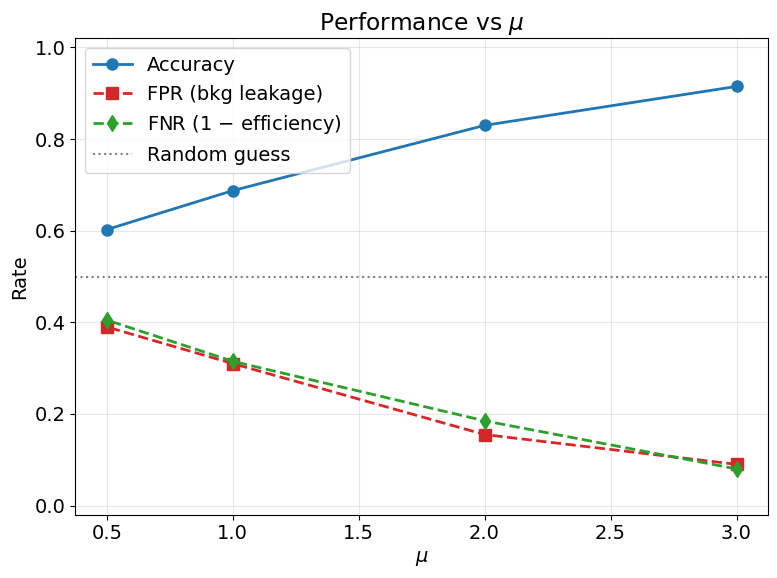

In [34]:
mu_arr  = [r[0] for r in results]
acc_arr = [r[1] for r in results]
fpr_arr = [r[2] for r in results]
fnr_arr = [r[3] for r in results]

fig, ax = plt.subplots()

ax.plot(mu_arr, acc_arr, 'o-', color='tab:blue', lw=2, ms=8, label='Accuracy')
ax.plot(mu_arr, fpr_arr, 's--', color='tab:red', lw=2, ms=8, label='FPR (bkg leakage)')
ax.plot(mu_arr, fnr_arr, 'd--', color='tab:green', lw=2, ms=8, label='FNR (1 $-$ efficiency)')

ax.axhline(0.5, color='gray', ls=':', label='Random guess')

ax.set_xlabel('$\\mu$')
ax.set_ylabel('Rate')
ax.set_title('Performance vs $\\mu$')
ax.legend()
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Accuracy $\to 0.5$ and error rates $\to 0.5$ as $\mu \to 0$.

---
## Problem 4: Interpretation

### 4.1  Why does performance degrade as $\mu \to 0$?

At $\mu = 0$:

$$\mathbf{x}_0 \sim \mathcal{N}(\mathbf{0},\, I), \qquad \mathbf{x}_1 \sim \mathcal{N}(\mathbf{0},\, I)$$

Same distribution. Complete overlap in feature space.

The classifier projects data onto a direction $\mathbf{w}$. The projected 1D distributions for the two classes are:

$$\mathbf{w}^T \mathbf{x}_0 \sim \mathcal{N}(0,\; \|\mathbf{w}\|^2)$$

$$\mathbf{w}^T \mathbf{x}_1 \sim \mathcal{N}(\mathbf{w}^T \boldsymbol{\mu},\; \|\mathbf{w}\|^2)$$

where $\boldsymbol{\mu} = (\mu, 0)^T$. The separation between the projected means in units of the projected standard deviation is:

$$d = \frac{|\mathbf{w}^T \boldsymbol{\mu}|}{\|\mathbf{w}\|}$$

The optimal $\mathbf{w}$ points along $\boldsymbol{\mu}$, giving:

$$d_{\max} = \frac{\|\boldsymbol{\mu}\|^2}{\|\boldsymbol{\mu}\|} = \|\boldsymbol{\mu}\| = \mu$$

For two 1D Gaussians separated by $d$ with equal variance, the Bayes-optimal accuracy is:

$$\text{Accuracy}_{\text{Bayes}} = \Phi\!\left(\frac{d}{2}\right)$$

Substituting $d = \mu$:

$$\text{Accuracy}_{\text{Bayes}} = \Phi\!\left(\frac{\mu}{2}\right)$$

Now take $\mu \to 0$:

$$\Phi\!\left(\frac{0}{2}\right) = \Phi(0) = 0.5$$

Even the best classifier gets 50%. No boundary $g(\mathbf{x}) = 0$ can help.

$\boxed{\text{The class distributions overlap completely — no direction } \mathbf{w} \text{ separates them. Accuracy} \to 50\%.}$

### 4.2  Does adding more data help when $\mu = 0$?

At $\mu = 0$, the Bayes limit is:

$$\text{Accuracy}_{\text{Bayes}} = \Phi\!\left(\frac{\mu}{2}\right) = \Phi(0) = 0.5$$

This is a property of the distributions, not of the sample size $N$.

More data $\Rightarrow$ better estimate of $\mathbf{w}$, $b$ $\Rightarrow$ but the true optimum still gives 50%.

In other words:

$$\lim_{N \to \infty} \text{Accuracy} = \Phi(0) = 0.5$$

$\boxed{\text{No. The classes are identical. More data just converges to 50\% more reliably.}}$

### 4.3  What assumption does a linear classifier make?

It assumes the boundary is a hyperplane:

$$g(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b = 0$$

- 2D $\Rightarrow$ line
- 3D $\Rightarrow$ plane  
- $n$D $\Rightarrow$ hyperplane

Decision rule:

$$\hat{y} = \begin{cases} 1 & g(\mathbf{x}) > 0 \\ 0 & g(\mathbf{x}) < 0 \end{cases}$$

"Classification is geometry — we are fitting a boundary, not a curve".

If the true boundary is curved (e.g. concentric rings), the linear model fails.

$\boxed{\text{Assumes the classes are separated by a hyperplane } g(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b = 0.}$